<a href="https://colab.research.google.com/github/emilyvip1967/gender_bias_cnn/blob/main/term_statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Working with Terms and Documents

This exercise starts off with term statistics computations and graphing. In the final section (for CS6200 students), you collect new documents to experiment with.

Read through this Jupyter notebook and fill in the parts marked with `TODO`.

## Sample Data

Start by looking at some sample data. We donwload the counts of terms in documents for the first one million tokens of a newswire collection.

In [1]:
!wget -O ap201001.json.gz https://github.com/dasmiq/cs6200-documents/blob/main/ap201001.json.gz?raw=true
!gunzip ap201001.json.gz

--2026-10-09 21:12:32--  https://github.com/dasmiq/cs6200-documents/blob/main/ap201001.json.gz?raw=true
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/dasmiq/cs6200-documents/raw/refs/heads/main/ap201001.json.gz [following]
--2026-10-09 21:12:32--  https://github.com/dasmiq/cs6200-documents/raw/refs/heads/main/ap201001.json.gz
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/dasmiq/cs6200-documents/refs/heads/main/ap201001.json.gz [following]
--2026-10-09 21:12:32--  https://raw.githubusercontent.com/dasmiq/cs6200-documents/refs/heads/main/ap201001.json.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185

We convert this file with one JSON record on each line to a list of dictionaries.

In [2]:
import json
rawfile = open('ap201001.json')
terms = [json.loads(line) for line in rawfile]

Here are the first ten records, showing the count of each term for each document and field. In this dataset, field only takes the values `body` or `title`.

In [3]:
terms[1:10]

[{'id': 'APW_ENG_20100101.0001', 'field': 'body', 'term': 'about', 'count': 1},
 {'id': 'APW_ENG_20100101.0001', 'field': 'body', 'term': 'abuse', 'count': 1},
 {'id': 'APW_ENG_20100101.0001',
  'field': 'body',
  'term': 'academy',
  'count': 1},
 {'id': 'APW_ENG_20100101.0001',
  'field': 'body',
  'term': 'accused',
  'count': 2},
 {'id': 'APW_ENG_20100101.0001',
  'field': 'body',
  'term': 'actress',
  'count': 1},
 {'id': 'APW_ENG_20100101.0001', 'field': 'body', 'term': 'ad', 'count': 1},
 {'id': 'APW_ENG_20100101.0001', 'field': 'body', 'term': 'after', 'count': 1},
 {'id': 'APW_ENG_20100101.0001',
  'field': 'body',
  'term': 'agenda',
  'count': 1},
 {'id': 'APW_ENG_20100101.0001',
  'field': 'body',
  'term': 'agreed',
  'count': 1}]

Each record has four fields:
* `id`, with the identifier for the document;
* `field`, with the region of the document containing a given term;
* `term`, with the lower-cased term; and
* `count`, with the number of times each term occurred in that field and document.

## Computing Term Statistics


If we look at the most frequent terms for a given document, we mostly see common function words, such as `the`, `and`, and `of`. Start exploring the dataset by computing some of these basic term statistics. You can make your life easier using data frame libraries such as `pandas`, core python libraries such as `collections`, or just simple list comprehensions.

Feel free to define helper functions in your code before computing the statistics we're looking for.

In [5]:
# TODO: Print the 10 terms from document APW_ENG_20100101.0001 with the highest count.
doc_id = "APW_ENG_20100101.0001"

doc_terms = [
    record for record in terms
    if record["id"] == doc_id
]

print("Number of records:", len(doc_terms))
print("First record:", doc_terms[0])

Number of records: 228
First record: {'id': 'APW_ENG_20100101.0001', 'field': 'body', 'term': 'a', 'count': 16}


In [6]:
# TODO: Print the 10 terms with the highest total count in the corpus.
from collections import Counter

term_counts = Counter()

for record in doc_terms:
    term_counts[record["term"]] += record["count"]

print(term_counts.most_common(10))

[('a', 16), ('the', 11), ('and', 10), ('brooks', 10), ('of', 10), ('to', 10), ('he', 9), ('in', 9), ('gomez', 8), ('for', 6)]


Raw counts may not be the most informative statistic. One common improvement is to use *inverse document frequency*, the inverse of the proportion of documents that contain a given term.

In [9]:
from collections import defaultdict

# Count distinct documents
doc_ids = {record["id"] for record in terms}
N = len(doc_ids)

# Collect distinct document IDs for each term
term_documents = defaultdict(set)

for record in terms:
    term_documents[record["term"]].add(record["id"])

# Count documents containing each term
df = {
    term: len(documents)
    for term, documents in term_documents.items()
}

print("Total documents:", N)
print("Document frequency of 'the':", df["the"])

Total documents: 2778
Document frequency of 'the': 2696


In [10]:
relative_df = df["the"] / N

print("Relative document frequency of 'the':", relative_df)

Relative document frequency of 'the': 0.9704823614110871


Empricially, we usually see better retrieval results if we rescale term frequency (within documents) and inverse document frequency (across documents) with the log function. Let the `tfidf` of term _t_ in document _d_ be:
```
tfidf(t, d) = log(count(t, d) + 1) * log(N / df(t))
```

Later in the course, we will show a probabilistic derivation of this quantity based on smoothing language models.

In [11]:
import math
from collections import Counter

# Combine counts across title and body for each term-document pair
pair_counts = Counter()

for record in terms:
    pair = (record["id"], record["term"])
    pair_counts[pair] += record["count"]

# Add TF-IDF to each record
tfidf_terms = []

for record in terms:
    new_record = record.copy()

    pair = (record["id"], record["term"])
    count = pair_counts[pair]
    term = record["term"]

    new_record["tfidf"] = (
        math.log(count + 1) * math.log(N / df[term])
    )

    tfidf_terms.append(new_record)

print("Records processed:", len(tfidf_terms))
print("Example:", tfidf_terms[0])

Records processed: 538301
Example: {'id': 'APW_ENG_20100101.0001', 'field': 'body', 'term': 'a', 'count': 16, 'tfidf': 0.21939360394288007}


In [12]:
top_20 = sorted(
    tfidf_terms,
    key=lambda record: record["tfidf"],
    reverse=True
)

seen = set()
shown = 0

for record in top_20:
    pair = (record["id"], record["term"])

    if pair in seen:
        continue

    seen.add(pair)

    print(
        record["id"],
        record["term"],
        round(record["tfidf"], 4)
    )

    shown += 1

    if shown == 20:
        break

APW_ENG_20100103.0028 guarani 23.2929
APW_ENG_20100105.0061 nomination 22.5194
APW_ENG_20100105.0014 greyhound 21.9852
APW_ENG_20100105.0446 methane 21.9852
APW_ENG_20100103.0015 kheire 21.4734
APW_ENG_20100107.0036 shakespeare 21.307
APW_ENG_20100105.0061 guild 20.6675
APW_ENG_20100106.0428 shakespeare 20.5021
APW_ENG_20100102.0197 elkhart 20.3387
APW_ENG_20100106.0075 magna 20.3387
APW_ENG_20100106.1325 sutton 20.2253
APW_ENG_20100104.0043 tohti 19.704
APW_ENG_20100104.0108 shiites 19.704
APW_ENG_20100105.0014 greyhounds 19.704
APW_ENG_20100107.0018 krewe 19.704
APW_ENG_20100107.0928 minhas 19.704
APW_ENG_20100103.0016 punk 19.5964
APW_ENG_20100105.0997 netbooks 19.3533
APW_ENG_20100105.1060 netbooks 19.3533
APW_ENG_20100105.0061 golden 19.3026


## Plotting Term Distributions

Besides frequencies and tf-idf values within documents, it is often helpful to look at the distrubitions of word frequencies in the whole collection. In class, we talk about the Zipf distribution of word rank versus frequency and Heaps' Law relating the number of distinct words to the number of tokens.

We might examine these distributions to see, for instance, if an unexpectedly large number of very rare terms occurs, which might indicate noise added to our data.

In [18]:
from collections import Counter

# Count term occurrences across the entire corpus
corpus_counts = Counter()

for record in terms:
    corpus_counts[record["term"]] += record["count"]

# Sort terms from highest to lowest frequency
frequency = corpus_counts.most_common()

print("Top 10 terms:", frequency[:10])
print("Number of distinct terms:", len(frequency))

Top 10 terms: [('the', 62216), ('to', 26931), ('in', 25659), ('a', 23383), ('of', 22326), ('and', 22125), ('said', 10888), ('for', 9716), ('on', 9382), ('that', 8942)]
Number of distinct terms: 27556


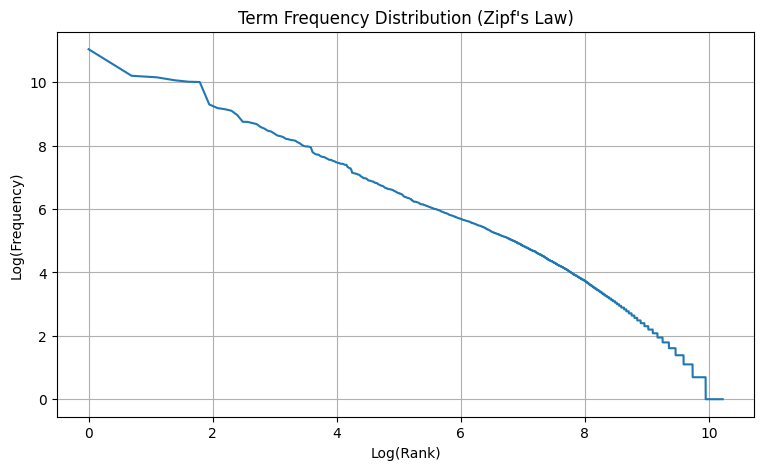

In [20]:
# TODO: Plot a graph of the log of the rank (starting at 1) on the x-axis,
# against the log of the frequency on the y-axis. You may use the matplotlib
# or other library.
import matplotlib.pyplot as plt
import math
from collections import Counter

corpus_counts = Counter()

for record in terms:
    corpus_counts[record["term"]] += record["count"]

frequency = corpus_counts.most_common()

ranks = range(1, len(frequency) + 1)

log_ranks = [math.log(r) for r in ranks]
log_frequencies = [math.log(count) for word, count in frequency]

plt.figure(figsize=(9, 5))
plt.plot(log_ranks, log_frequencies)

plt.xlabel("Log(Rank)")
plt.ylabel("Log(Frequency)")
plt.title("Term Frequency Distribution (Zipf's Law)")
plt.grid(True)
plt.show()

In [21]:
# TODO: Compute the number of tokens in the corpus.
# Remember to count each occurrence of each word. For instance, the 62,216
# instances of "the" will all count here.
ntokens = sum(record["count"] for record in terms)

print("Total tokens:", ntokens)

Total tokens: 1000000


In [22]:
print("Counts match:", ntokens == sum(corpus_counts.values()))

Counts match: True


In [23]:
# TODO: Compute the proportion of tokens made up by the top 10 most
# frequent words.
top_10_tokens = sum(count for word, count in frequency[:10])

top_10_proportion = top_10_tokens / ntokens

print("Top 10 token count:", top_10_tokens)
print("Top 10 proportion:", top_10_proportion)

Top 10 token count: 221568
Top 10 proportion: 0.221568


In [24]:
# TODO: Compute the proportion of tokens made up by the words that occur
# exactly once in this collection.
single_occurrence_tokens = sum(
    count for word, count in frequency
    if count == 1
)

single_occurrence_proportion = single_occurrence_tokens / ntokens

print("Single-occurrence token count:", single_occurrence_tokens)
print("Single-occurrence proportion:", single_occurrence_proportion)

Single-occurrence token count: 6641
Single-occurrence proportion: 0.006641


## Acquiring New Documents (CS6200)

This section is required for students in CS6200 and worth up to 10 points extra credit for students in CS4220.

For this assignment so far, you've worked with data that's already been extracted, tokenized, and counted. In this final section, you'll explore acquiring new data.

One common way of acquiring data is through application programming interfaces (APIs) to various databases. The Library of Congress's [_Chronicling America_](https://www.loc.gov/collections/chronicling-america/about-this-collection/) site aggregates digitized US newspapers from the past two hundred years, such as the [_Milwaukee Leader_](https://www.loc.gov/resource/sn83045293/1926-09-26/ed-1/) from 100 years ago.

You can use [the API](https://libraryofcongress.github.io/data-exploration/loc.gov%20JSON%20API/Chronicling_America/README.html) to retrieve JSON data listing all issues of the _Milwaukee Leader_ from 1926: https://www.loc.gov/item/sn83045293/?st=calendar&year=1926&fo=json

Note the list in the `issue_data` field. For example, here is the record for the January 17, 1926, issue: https://www.loc.gov/item/sn83045462/1920-04-21/ed-1/. To get the information structured in JSON from the API, we append `?fo=json`, i.e.: https://www.loc.gov/item/sn83045462/1920-04-21/ed-1/?fo=json

In that issue record, you'll see links to data about individual pages in various data formats, such as JPEG, PDF, XML, and plain text, which is what we want here: https://tile.loc.gov/text-services/word-coordinates-service?segment=/service/ndnp/dlc/batch_dlc_ixtl_ver01/data/sn83045462/00280656732/1920042101/0366.xml&format=alto_xml&full_text=1

This plain text was transcribed from the digital images of the microfilm of old pages using optical character recognition (OCR) models, and so contains errors.

Your task is to acquire and analyze the issues of the _Milwaukee Leader_ from the month of September, 1926, i.e., the issues with a date field that starts with `1926-09`. This should be about the same amount of data as the million words from the Associated Press you analyzed in the last section.

Write code that calls the _Chronicling America_ API to download and extract the text from the _Milwaukee Leader_ from September 1926. You can use the `json` library from above and any other libraries you wish to fetch data from URLs. As you would when working with any production API, you may need to limit your rate of requests.

In [32]:
# TODO: Data acquisition code here.
import requests

url = "https://www.loc.gov/item/sn83045293/"

params = {
    "st": "calendar",
    "year": "1926",
    "fo": "json"
}

response = requests.get(url, params=params, timeout=30)
response.raise_for_status()

data = response.json()

print("Available fields:", list(data.keys()))
print("Issue data type:", type(data.get("issue_data")))

calendar = data["calendar_data"]

print("Calendar type:", type(calendar))
print("Calendar preview:", str(calendar)[:1500])
print("Calendar keys:", list(calendar.keys()))

for key, value in calendar.items():
    print(key, ":", type(value))
    issues = calendar["issue_data"]

september_issues = [
    issue for issue in issues
    if str(issue.get("date", "")).startswith("1926-09")
]

print("Total issues in response:", len(issues))
print("September 1926 issues:", len(september_issues))

if september_issues:
    print("First September issue:", september_issues[0])
# Get the URL of the first September issue
issue_url = september_issues[0]["urls"][0]["url"]

# Request its JSON metadata
response = requests.get(
    issue_url,
    params={"fo": "json"},
    timeout=30
)
response.raise_for_status()

issue_data = response.json()

print("Issue URL:", issue_url)
print("Available fields:", list(issue_data.keys()))
print("Item fields:", list(issue_data.get("item", {}).keys()))
print("Resources preview:", str(issue_data.get("resources", []))[:1500])

Available fields: ['articles_and_essays', 'calendar_data', 'calendar_url', 'cite_this', 'front_pages_url', 'holdings_url', 'item', 'more_like_this', 'notice', 'options', 'related_items', 'resources', 'timestamp', 'title_image_url']
Issue data type: <class 'NoneType'>
Calendar type: <class 'dict'>
Calendar preview: {'dropdown_menu_data': [1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932], 'issue_data': [{'date': '1926-01-01', 'urls': [{'label': 'Edition 1', 'url': 'https://www.loc.gov/item/sn83045293/1926-01-01/ed-1/'}]}, {'date': '1926-01-02', 'urls': [{'label': 'Edition 1', 'url': 'https://www.loc.gov/item/sn83045293/1926-01-02/ed-1/'}]}, {'date': '1926-01-03', 'urls': [{'label': 'Edition 1', 'url': 'https://www.loc.gov/item/sn83045293/1926-01-03/ed-1/'}]}, {'date': '1926-01-05', 'urls': [{'label': 'Edition 1', 'url': 'https://www.loc.gov/item/sn83045293/1926-01-05/ed-1/'}]}, {'date': '1926-01-06', 'urls

In [34]:
resources = issue_data.get("resources", [])

print("Number of resources:", len(resources))

if resources:
    first_resource = resources[0]
    print("Resource fields:", list(first_resource.keys()))

    files = first_resource.get("files", [])
    print("Number of file groups:", len(files))

    if files:
        print("First file group type:", type(files[0]))
        print("First file group:", str(files[0])[:2000])

Number of resources: 1
Resource fields: ['files', 'image', 'url', 'word_coordinates']
Number of file groups: 14
First file group type: <class 'list'>
First file group: [{'height': 9635, 'info': 'https://tile.loc.gov/image-services/iiif/service:ndnp:whi:batch_whi_havarti_ver01:data:sn83045293:00542869057:1926090101:0463/info.json', 'mimetype': 'image/jp2', 'size': 8647476, 'url': 'https://tile.loc.gov/storage-services/service/ndnp/whi/batch_whi_havarti_ver01/data/sn83045293/00542869057/1926090101/0463.jp2', 'use': '', 'width': 7186}, {'mimetype': 'application/pdf', 'url': 'https://tile.loc.gov/storage-services/service/ndnp/whi/batch_whi_havarti_ver01/data/sn83045293/00542869057/1926090101/0463.pdf', 'use': ''}, {'mimetype': 'text/xml', 'url': 'https://tile.loc.gov/storage-services/service/ndnp/whi/batch_whi_havarti_ver01/data/sn83045293/00542869057/1926090101/0463.xml', 'use': ''}, {'height': 301, 'levels': 1, 'mimetype': 'image/jpeg', 'url': 'https://tile.loc.gov/image-services/iiif/se

In [35]:
# Inspect the word-coordinates information
print("Word coordinates:")
print(str(first_resource.get("word_coordinates"))[:2000])

# Inspect the available formats for the first page
print("\nFirst page file formats:")

for file in files[0]:
    print({
        "mimetype": file.get("mimetype"),
        "url": file.get("url"),
        "size": file.get("size")
    })

Word coordinates:
https://tile.loc.gov/text-services/word-coordinates-service

First page file formats:
{'mimetype': 'image/jp2', 'url': 'https://tile.loc.gov/storage-services/service/ndnp/whi/batch_whi_havarti_ver01/data/sn83045293/00542869057/1926090101/0463.jp2', 'size': 8647476}
{'mimetype': 'application/pdf', 'url': 'https://tile.loc.gov/storage-services/service/ndnp/whi/batch_whi_havarti_ver01/data/sn83045293/00542869057/1926090101/0463.pdf', 'size': None}
{'mimetype': 'text/xml', 'url': 'https://tile.loc.gov/storage-services/service/ndnp/whi/batch_whi_havarti_ver01/data/sn83045293/00542869057/1926090101/0463.xml', 'size': None}
{'mimetype': 'image/jpeg', 'url': 'https://tile.loc.gov/image-services/iiif/service:ndnp:whi:batch_whi_havarti_ver01:data:sn83045293:00542869057:1926090101:0463/full/pct:3.125/0/default.jpg', 'size': None}
{'mimetype': 'image/jpeg', 'url': 'https://tile.loc.gov/image-services/iiif/service:ndnp:whi:batch_whi_havarti_ver01:data:sn83045293:00542869057:192609

In [36]:
from urllib.parse import urlparse

# Find the XML file for the first page
xml_file = next(
    file for file in files[0]
    if file.get("mimetype") == "text/xml"
)

xml_url = xml_file["url"]

# Convert the storage URL into the segment path required by the API
segment = urlparse(xml_url).path.replace(
    "/storage-services", "", 1
)

text_url = first_resource["word_coordinates"]

response = requests.get(
    text_url,
    params={
        "segment": segment,
        "format": "alto_xml",
        "full_text": 1
    },
    timeout=60
)

response.raise_for_status()
page_text = response.text

print("Response type:", response.headers.get("Content-Type"))
print("Characters retrieved:", len(page_text))
print("Text preview:")
print(page_text[:1000])

Response type: application/json
Characters retrieved: 25486
Text preview:
{"/service/ndnp/whi/batch_whi_havarti_ver01/data/sn83045293/00542869057/1926090101/0463.xml":{"full_text":"\"The present social order is a\nridiculous mechanism, in which\nportions of the whole are in con\nflict and acting against the\nwhole. \u2014Charles Fourier.\nVol. 15\u2014No. 227.\nFINDINGS\nWILL BEE\nAnd now once more \u2014we\nmust warn all of our members\nand sympathizers to keep away\nfrom either the Republican or\nthe Democratic primary.\nMost of them are probably\naware that at the primary elec\ntion one can not \u201csplit\u201d the\nticket. That is, you cannot\nvote for a Socialist for a cer\ntain office, and then also try to\nhelp a friend on the Republican\nor Democratic ticket for another\noffice\u2014because the different\nparties are on different sheets\nand you can vote only on one\nsheet.\nIn other words, at the primary\nyou must vote a straight ticket.\nOtherwise you lose your vote\nand wea

In [37]:
# Convert the JSON response to a Python dictionary
page_data = response.json()

# Extract the text from the first entry
page_record = next(iter(page_data.values()))
page_text = page_record["full_text"]

print("Characters of newspaper text:", len(page_text))
print("Text preview:")
print(page_text[:500])

Characters of newspaper text: 23781
Text preview:
"The present social order is a
ridiculous mechanism, in which
portions of the whole are in con
flict and acting against the
whole. —Charles Fourier.
Vol. 15—No. 227.
FINDINGS
WILL BEE
And now once more —we
must warn all of our members
and sympathizers to keep away
from either the Republican or
the Democratic primary.
Most of them are probably
aware that at the primary elec
tion one can not “split” the
ticket. That is, you cannot
vote for a Socialist for a cer
tain office, and then also try to
he


In [38]:
import requests
import time
from urllib.parse import urlparse

def download_issue(issue):
    issue_url = issue["urls"][0]["url"]

    # Retrieve issue metadata
    result = requests.get(
        issue_url,
        params={"fo": "json"},
        timeout=60
    )
    result.raise_for_status()

    metadata = result.json()
    page_texts = []

    for resource in metadata.get("resources", []):
        for page_files in resource.get("files", []):

            xml_files = [
                f for f in page_files
                if f.get("mimetype") == "text/xml"
                and f.get("url")
            ]

            if not xml_files:
                continue

            xml_url = xml_files[0]["url"]

            segment = urlparse(xml_url).path.replace(
                "/storage-services", "", 1
            )

            try:
                response = requests.get(
                    resource["word_coordinates"],
                    params={
                        "segment": segment,
                        "format": "alto_xml",
                        "full_text": 1
                    },
                    timeout=60
                )
                response.raise_for_status()

                page_data = response.json()
                page_record = next(iter(page_data.values()))
                text = page_record["full_text"]

                page_texts.append(text)

            except (requests.RequestException, ValueError,
                    KeyError, StopIteration) as error:
                print("Page failed:", segment, error)

            time.sleep(1)

    return page_texts


# Test on the first September issue
first_issue_pages = download_issue(september_issues[0])

print("Pages downloaded:", len(first_issue_pages))
print("Total characters:", sum(len(p) for p in first_issue_pages))

Pages downloaded: 14
Total characters: 345455


In [39]:
# Preserve the first issue we already downloaded
all_pages = list(first_issue_pages)

# Download the remaining 24 issues
for i, issue in enumerate(september_issues[1:], start=2):
    print(f"Downloading issue {i}/25: {issue['date']}")

    try:
        pages = download_issue(issue)
        all_pages.extend(pages)
        print(f"  Downloaded {len(pages)} pages")

    except requests.RequestException as error:
        print(f"  Issue failed: {error}")

    time.sleep(1)

print("Total pages downloaded:", len(all_pages))
print("Total characters:", sum(len(p) for p in all_pages))

  Downloaded 14 pages
  Downloaded 14 pages
  Downloaded 16 pages
  Downloaded 16 pages
  Downloaded 14 pages
  Downloaded 14 pages
  Downloaded 14 pages
  Downloaded 16 pages
  Downloaded 14 pages
Page failed: /service/ndnp/whi/batch_whi_havarti_ver01/data/sn83045293/00542869057/1926091401/0627.xml ('Connection broken: IncompleteRead(8192 bytes read, 15937 more expected)', IncompleteRead(8192 bytes read, 15937 more expected))
  Downloaded 13 pages
  Downloaded 14 pages
  Downloaded 14 pages
  Downloaded 14 pages
  Downloaded 16 pages
  Downloaded 14 pages
  Downloaded 14 pages
  Downloaded 16 pages
  Downloaded 16 pages
  Downloaded 14 pages
  Downloaded 20 pages
  Downloaded 14 pages
  Downloaded 14 pages
  Downloaded 14 pages
  Downloaded 14 pages
Total pages downloaded: 367
Total characters: 8877394


In [40]:
with open("milwaukee_leader_sep1926.txt", "w", encoding="utf-8") as f:
    for page in all_pages:
        f.write(page)
        f.write("\n\n")

print("Saved newspaper collection.")

Saved newspaper collection.


In [41]:
import re
from collections import Counter

all_text = "\n".join(all_pages)

words = re.findall(r"[a-z]+", all_text.lower())
new_counts = Counter(words)

print("Total tokens:", len(words))
print("Distinct terms:", len(new_counts))
print("Top 10 words:", new_counts.most_common(10))

Total tokens: 1495361
Distinct terms: 65946
Top 10 words: [('the', 81986), ('of', 45055), ('and', 37272), ('to', 32081), ('a', 28525), ('in', 26581), ('for', 14126), ('is', 11713), ('s', 10880), ('that', 10347)]


In [42]:
# Proportion of tokens from the top 10 words
top10_tokens = sum(count for word, count in new_counts.most_common(10))
top10_proportion = top10_tokens / len(words)

# Proportion of tokens occurring exactly once
singletons = sum(
    count for word, count in new_counts.items()
    if count == 1
)
singleton_proportion = singletons / len(words)

print("Top 10 token proportion:", top10_proportion)
print("Singleton token proportion:", singleton_proportion)

Top 10 token proportion: 0.19966148642367965
Singleton token proportion: 0.022781121080461507


Write code to tokenize the text and count the resulting terms in each document. Since this data comes from automatically transcribing printed pages, some words may be hyphenated across line breaks. There is more than one right way to tokenize this data, so add comments to your code documenting your choices.

In [43]:
# TODO: Tokenization code here.
import re
from collections import Counter

# Store token counts separately for each newspaper page.
document_counts = []

for page in all_pages:
    # Join words explicitly hyphenated across line breaks.
    # Example: "govern-\nment" becomes "government".
    cleaned = re.sub(r"([A-Za-z])-\s*\n\s*([A-Za-z])", r"\1\2", page)

    # Convert to lowercase and extract alphabetic words.
    tokens = re.findall(r"[a-z]+", cleaned.lower())

    document_counts.append(Counter(tokens))

# Combine counts from every page.
new_counts = Counter()

for counts in document_counts:
    new_counts.update(counts)

new_ntokens = sum(new_counts.values())

print("Documents (pages):", len(document_counts))
print("Total tokens:", new_ntokens)
print("Distinct terms:", len(new_counts))
print("Top 10:", new_counts.most_common(10))

Documents (pages): 367
Total tokens: 1494218
Distinct terms: 66431
Top 10: [('the', 81954), ('of', 45048), ('and', 37269), ('to', 32066), ('a', 28514), ('in', 26560), ('for', 14121), ('is', 11711), ('s', 10869), ('that', 10344)]


Plot a graph of the log rank against log frequency for your collection, as you did for the sample collection above.

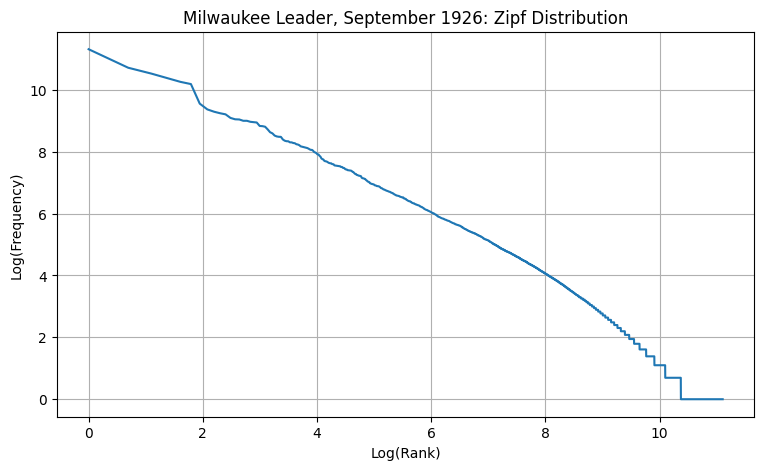

In [44]:
# TODO: Plotting code here.
import matplotlib.pyplot as plt
import math

new_frequency = new_counts.most_common()

new_log_ranks = [
    math.log(rank)
    for rank in range(1, len(new_frequency) + 1)
]

new_log_frequencies = [
    math.log(count)
    for word, count in new_frequency
]

plt.figure(figsize=(9, 5))
plt.plot(new_log_ranks, new_log_frequencies)

plt.xlabel("Log(Rank)")
plt.ylabel("Log(Frequency)")
plt.title("Milwaukee Leader, September 1926: Zipf Distribution")
plt.grid(True)
plt.show()

In [45]:
# TODO: Compute the proportion of tokens made up by the top 10 most
# frequent words in this collection.
new_top10 = sum(count for word, count in new_counts.most_common(10))

new_top10_proportion = new_top10 / new_ntokens

print("Top 10 proportion:", new_top10_proportion)

Top 10 proportion: 0.19974060009985156


In [46]:
# TODO: Compute the proportion of tokens made up by the words that occur
# exactly once in this collection.
new_singletons = sum(
    1 for count in new_counts.values()
    if count == 1
)

new_singleton_proportion = new_singletons / new_ntokens

print("Singleton proportion:", new_singleton_proportion)

Singleton proportion: 0.023117108748522637


What do you observe about the differences between the distributions of the Associated Press and Milwaukee Leader collections?


Both the Associated Press (AP) and Milwaukee Leader collections exhibit Zipf-like word frequency distributions. A small number of common words occur very frequently, while a large number of words occur relatively rarely. Both log-rank versus log-frequency plots show a generally downward-sloping relationship.

The Milwaukee Leader collection contains 66,431 distinct terms compared with 27,556 in the AP collection. However, the Milwaukee Leader also contains approximately 49% more tokens, which partially explains its larger vocabulary.

Other possible explanations include differences in historical vocabulary, newspaper content, tokenization methods, and OCR errors. Since the Milwaukee Leader was digitized using optical character recognition, transcription mistakes and incorrectly split or joined words can introduce additional rare terms.

These factors may affect the low-frequency tail of the distribution, even though both collections follow the general pattern described by Zipf's Law.